In [11]:
from koala.lattice import Lattice
import numpy as np
import numpy.typing as npt
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from pfapack.ctypes import pfaffian
import pfapack.ctypes as cpf
import ctypes
from scipy import linalg as la

from dimer_models.kasteleyn import kasteleyn_matrix

In [12]:
def find_kasteleyn_number(
    lattice: Lattice, s_log=False, return_individual_sectors=False
):
    """Given a lattice, find the total number of dimerisations using Kasteleyn's method.

    Args:
        lattice (Lattice): The lattice object, must have operiodic or open boundaries.
        s_log (bool, optional): If True, returns the result as a tuple where
            out[0]* 10 ** out[1] is the number of dimerisations. Defaults to False.

    Raises:
        Exception: Kasteleyn only works in periodic and open boundaries


    Returns:
        int : _description_
    """

    # open boundaries
    if np.all(lattice.boundary_conditions == False):
        ujk = ujk_from_fluxes(lattice, np.array([-1] * lattice.n_plaquettes))
        assert np.all(fluxes_from_ujk(lattice, ujk) == -1)
        K = kasteleyn_matrix(lattice, ujk)

        if s_log:
            out = _fast_pfaffian(K)
            return (abs(out[0]), out[1])
        else:
            return abs(round(pfaffian(K)))

    # periodic boundaries
    elif np.all(lattice.boundary_conditions == True):

        # make ujk sets
        ujk = ujk_from_fluxes(lattice, np.array([-1] * lattice.n_plaquettes))
        x_boundary_edges = np.where(lattice.edges.crossing[:, 0] != 0)
        y_boundary_edges = np.where(lattice.edges.crossing[:, 1] != 0)
        all_ujks = np.array([[ujk] * 2] * 2)
        all_ujks[1, :, x_boundary_edges] *= -1
        all_ujks[:, 1, y_boundary_edges] *= -1
        ujk_list = all_ujks.reshape([-1, all_ujks.shape[-1]])

        check = ujk_list.reshape(all_ujks.shape)
        assert np.all(check == all_ujks)

        print(ujk_list.shape)

        n_vals = []
        for u in ujk_list:

            # solve the pfaffians
            assert np.all(fluxes_from_ujk(lattice, u) == -1)
            K = kasteleyn_matrix(lattice, u)
            if s_log:
                n_vals.append(_fast_pfaffian(K))
            else:
                n_vals.append(round(pfaffian(K)))

        print(np.array(n_vals).shape)
        # find the right combination to return
        if s_log:
            mags = np.array([x[0] for x in n_vals])
            pows = np.array([x[1] for x in n_vals])

            max_power = max(pows)
            defecit = pows - max_power
            mags = mags * (10 ** (defecit))

            m = np.ones([4, 4]) - 2 * np.eye(4)
            options = np.abs(np.sum(m * np.array(mags), axis=1)) / 2

            return np.max(options), max_power

        else:
            m = np.ones([4, 4]) - 2 * np.eye(4)
            options = np.abs(np.sum(m * np.array(n_vals), axis=1)) // 2

            return int(np.max(options))

    else:
        raise Exception("Kasteleyn only works in periodic and open boundaries")

(4, 30)
(4,)


36

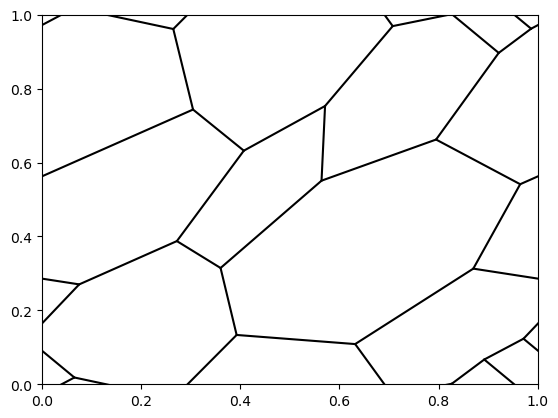

In [13]:
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import plotting as pl


lattice = generate_lattice(uniform(10))
pl.plot_edges(lattice)
find_kasteleyn_number(lattice)